# 04 Machine-Learning Model Benchmark

This notebook compares five PM2.5 estimation models using the same
engineered predictors and a common year-month-stratified, date-disjoint
evaluation protocol.

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/model_benchmark/`

## Research Question

**RQ3.** How accurately do conventional machine-learning models and a
feature-based neural network estimate PM2.5 under a common multi-source
evaluation protocol?

## Workflow Overview

1. Dataset and benchmark configuration
2. Development cross-validation and common hold-out evaluation
3. Best-model diagnostics and supplementary robustness checks


## Setup

In [9]:
import sys
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.config as config
import src.features.evaluation as evaluation
import src.models.benchmark as benchmark
import src.models.plots as benchmark_plots
import src.plot_style as plot_style

importlib.reload(config)
importlib.reload(evaluation)
importlib.reload(benchmark)
importlib.reload(plot_style)
importlib.reload(benchmark_plots)

COLORS = plot_style.COLORS
CONCENTRATION_COLORS = plot_style.CONCENTRATION_COLORS
apply_thesis_style = plot_style.apply_thesis_style

apply_thesis_style()

RESULTS_DIR = PROJECT_ROOT / "results" / "model_benchmark"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)


Project root: /Users/qingxuan/Desktop/webcam-pm25-benchmark
Results directory: /Users/qingxuan/Desktop/webcam-pm25-benchmark/results/model_benchmark


## 1. Dataset and Benchmark Setup

This section defines the complete-case dataset, common split, and fixed
model configurations used throughout the benchmark.

### 1.1 Dataset and Engineered Feature Set

The target and engineered predictors follow Notebook 3. Complete cases
are retained, and observations from the same date share one group.

In [10]:
# Load data and define the benchmark columns.
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
df = (
    pd.read_csv(DATA_PATH, parse_dates=["time"])
    .sort_values("time")
    .reset_index(drop=True)
)

TARGET = config.TARGET
FEATURES = config.ALL_FEATURES
required_columns = ["time", TARGET, *FEATURES]
missing_columns = [
    column for column in required_columns if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Retain complete cases and create date- and month-level groups.
benchmark_df = (
    df[required_columns]
    .dropna()
    .reset_index(drop=True)
)
if benchmark_df.empty:
    raise ValueError("No complete samples are available for benchmarking.")
benchmark_df["date_group"] = benchmark_df["time"].dt.normalize()
benchmark_df["year_month"] = (
    benchmark_df["time"].dt.to_period("M").astype(str)
)

print(
    f"Complete-case dataset: {len(benchmark_df):,} of {len(df):,} samples; "
    f"{benchmark_df['date_group'].nunique()} independent dates across "
    f"{benchmark_df['year_month'].nunique()} observed months."
)


Complete-case dataset: 3,625 of 3,625 samples; 209 independent dates across 13 observed months.


In [11]:
# Use config.py as the single source of truth for feature groups.
feature_groups = config.FEATURE_GROUPS
grouped_features = [
    feature
    for features in feature_groups.values()
    for feature in features
]

# This exact-order check also detects missing, extra, or duplicated features.
if grouped_features != FEATURES:
    raise ValueError("FEATURE_GROUPS and ALL_FEATURES are inconsistent.")

feature_group_summary = pd.DataFrame(
    {
        "Feature Group": [*feature_groups, "Total"],
        "Number of Features": [
            *[len(features) for features in feature_groups.values()],
            len(FEATURES),
        ],
    }
)

display(feature_group_summary)

,Feature Group,Number of Features
0,Image,18
1,ERA5,18
2,ARPA,7
3,Temporal,12
4,Total,55


### 1.2 Benchmark Protocol

Complete dates are allocated to the development and common hold-out sets
within each observed year-month. Models are ranked using unweighted,
date-grouped development CV and evaluated once on the common hold-out set.
Equal-year-month weighting and strict temporal generalization are examined
separately in Section 5.2.


In [12]:
# Benchmark configuration
FINAL_TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 24
MODEL_RANDOM_STATE = 42

if not 0 < FINAL_TEST_SIZE < 1:
    raise ValueError("FINAL_TEST_SIZE must be between 0 and 1.")
if N_SPLITS < 2:
    raise ValueError("N_SPLITS must be at least 2.")


In [13]:
# Create the year-month-aware, date-disjoint common split.
development_df, final_test_df = evaluation.balanced_month_group_split(
    benchmark_df,
    time_column="time",
    test_size=FINAL_TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)

if development_df.empty or final_test_df.empty:
    raise ValueError("The development or common hold-out set is empty.")
if set(development_df["date_group"]) & set(final_test_df["date_group"]):
    raise ValueError("Development and hold-out sets contain shared dates.")
if len(development_df) + len(final_test_df) != len(benchmark_df):
    raise ValueError("Split sample counts do not match the benchmark dataset.")

split_frames = {
    "Complete dataset": benchmark_df,
    "Development set": development_df,
    "Common hold-out": final_test_df,
}
split_summary = pd.DataFrame([
    {
        "Subset": name,
        "Samples": len(subset),
        "Independent dates": subset["date_group"].nunique(),
        "Observed months": subset["year_month"].nunique(),
        "Percentage": len(subset) / len(benchmark_df) * 100,
        "Mean PM2.5": subset[TARGET].mean(),
        "Median PM2.5": subset[TARGET].median(),
        "Maximum PM2.5": subset[TARGET].max(),
        "Samples >35": subset[TARGET].gt(35).sum(),
    }
    for name, subset in split_frames.items()
])
display(split_summary.round(2))


,Subset,Samples,Independent dates,Observed months,Percentage,Mean PM2.5,Median PM2.5,Maximum PM2.5,Samples >35
0,Complete dataset,3625,209,13,100.00,14.55,11.23,93.11,266
1,Development set,2905,167,13,80.14,14.69,11.30,93.11,227
2,Common hold-out,720,42,13,19.86,13.99,10.81,64.35,39


### 1.3 Benchmark Models

All models use the same 55 engineered predictors. Ridge, Decision Tree,
Random Forest, Gradient Boosting, and MLP provide an input-controlled
comparison of linear, tree-based, ensemble, and neural-network
approaches. Configurations were fixed following the development-CV regularization
development-only regularization diagnostics, are stored in `benchmark.py`, and are not
adjusted using the common hold-out set.

The MLP uses training-loss convergence without a randomly sampled
internal validation subset; model comparison is based on the common
date-grouped CV folds. Raw-image CNN models are evaluated in Notebook 5.

In [14]:
# Load model configurations and their display metadata from benchmark.py.
benchmark_models = benchmark.get_benchmark_models(
    random_state=MODEL_RANDOM_STATE
)
MODEL_ORDER = list(benchmark_models)
model_summary = benchmark.get_model_summary()

if model_summary["Model"].tolist() != MODEL_ORDER:
    raise ValueError("Model definitions and summary metadata are inconsistent.")

display(model_summary)

,Model,Model family,Scaling,Key configuration
0,Ridge,Linear regression,Standardised,alpha=100
1,Decision Tree,Regression tree,Not required,max_depth=4; min_samples_leaf=25
2,Random Forest,Bagging ensemble,Not required,n_estimators=500; max_depth=8; max_features=sqrt
3,Gradient Boosting,Boosting ensemble,Not required,n_estimators=450; learning_rate=0.08; max_dept...
4,MLP,Feed-forward neural network,Standardised,"layers=(16,); alpha=1.0; max_iter=3000"


## 2. Development Cross-Validation Benchmark

### 2.1 Engineered-Feature Model Evaluation

All models are evaluated on identical unweighted, date-grouped folds
within the development set. The common hold-out remains untouched. MAE,
RMSE, and R² remain the primary metrics; MAPE, SMAPE, and mean-normalised
NRMSE are reported as supplementary dimensionless measures for comparison
across concentration contexts. Because MAPE is sensitive to observations
near zero, it is interpreted together with SMAPE and NRMSE.


In [15]:
# Evaluate the five engineered-feature models using
# unweighted date-grouped development cross-validation

benchmark_cv_results = []
benchmark_fold_results = []

for model_name, model in benchmark_models.items():

    (
        summary,
        fold_results,
        _,
        _,
    ) = evaluation.evaluate_feature_set(
        model=model,
        model_name=model_name,
        feature_set_name="All Features",
        feature_list=FEATURES,
        development_df=development_df,

        # Required by the interface but not accessed
        # because evaluate_test=False.
        test_df=final_test_df,

        target=TARGET,
        n_splits=N_SPLITS,
        random_state=MODEL_RANDOM_STATE,

        # Keep complete dates in the same fold.
        group_column="date_group",

        # No inverse-frequency training or metric weights.
        balance_column=None,

        # The common hold-out set remains unused.
        evaluate_test=False,

        # Reuse these fits for the Train–CV diagnostic.
        include_train_metrics=True,
    )

    benchmark_cv_results.append(
        summary
    )

    benchmark_fold_results.append(
        fold_results.assign(
            Model=model_name
        )
    )

benchmark_cv_results = pd.concat(
    benchmark_cv_results,
    ignore_index=True,
)

benchmark_fold_results = pd.concat(
    benchmark_fold_results,
    ignore_index=True,
)


### 2.2 Engineered-Feature Model Performance

Mean R², RMSE, MAE, MAPE, SMAPE, and NRMSE summarise predictive performance
across the five folds; their standard deviations describe fold-to-fold
stability. Percentage-based metrics and NRMSE are expressed in percent.


In [16]:
# Summarise development cross-validation performance

cv_columns = [
    "Model",
    "Variables",
    "CV MAE",
    "CV MAE Std",
    "CV RMSE",
    "CV RMSE Std",
    "CV R2",
    "CV R2 Std",
    "CV MAPE",
    "CV MAPE Std",
    "CV SMAPE",
    "CV SMAPE Std",
    "CV NRMSE",
    "CV NRMSE Std",
]

benchmark_cv_summary = (
    benchmark_cv_results[cv_columns]
    .sort_values(
        by=[
            "CV R2",
            "CV RMSE",
            "CV MAE",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

benchmark_cv_summary.insert(
    0,
    "Rank",
    range(
        1,
        len(benchmark_cv_summary) + 1,
    ),
)

benchmark_cv_display = (
    benchmark_cv_summary.copy()
)

metric_columns = [
    "CV MAE",
    "CV MAE Std",
    "CV RMSE",
    "CV RMSE Std",
    "CV R2",
    "CV R2 Std",
    "CV MAPE",
    "CV MAPE Std",
    "CV SMAPE",
    "CV SMAPE Std",
    "CV NRMSE",
    "CV NRMSE Std",
]

benchmark_cv_display[
    metric_columns
] = (
    benchmark_cv_display[
        metric_columns
    ]
    .round(3)
)

display(benchmark_cv_display)

,Rank,Model,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,CV MAPE,CV MAPE Std,CV SMAPE,CV SMAPE Std,CV NRMSE,CV NRMSE Std
0,1,Gradient Boosting,55,4.380,0.359,5.810,0.508,0.739,0.036,49.858,8.756,35.926,2.781,39.663,3.266
1,2,Random Forest,55,4.673,0.334,6.199,0.613,0.702,0.046,58.992,12.982,37.564,3.870,42.358,4.533
2,3,Ridge,55,5.128,0.495,6.681,0.707,0.656,0.042,59.524,10.348,43.762,2.309,45.473,2.469
3,4,Decision Tree,55,5.244,0.556,7.002,0.750,0.623,0.042,66.350,16.552,41.370,3.913,47.729,4.045
4,5,MLP,55,5.360,0.295,7.096,0.540,0.613,0.014,59.873,8.431,47.063,3.029,48.352,1.213


### 2.3 Train–CV Overfitting Diagnostic

Training and validation R² from the same date-grouped CV fits are
compared as an overfitting diagnostic. This Train–CV difference is
distinct from the later CV–hold-out difference.

In [17]:
# Summarise training and validation R² from the existing CV fits.
train_cv_fold_results = benchmark_fold_results.copy()
train_cv_fold_results["Train-CV R2 Gap"] = (
    train_cv_fold_results["Train R2"]
    - train_cv_fold_results["R2"]
)

train_cv_gap_summary = (
    train_cv_fold_results
    .groupby("Model", as_index=False)
    .agg(
        Mean_Train_R2=("Train R2", "mean"),
        Mean_CV_R2=("R2", "mean"),
        Train_CV_R2_Gap=("Train-CV R2 Gap", "mean"),
    )
    .rename(
        columns={
            "Mean_Train_R2": "Mean Train R2",
            "Mean_CV_R2": "Mean CV R2",
            "Train_CV_R2_Gap": "Train-CV R2 Gap",
        }
    )
    .sort_values("Mean CV R2", ascending=False)
    .reset_index(drop=True)
)

display(train_cv_gap_summary.round(3))

TRAIN_CV_GAP_PATH = RESULTS_DIR / "train_cv_r2_gap_summary.csv"
train_cv_gap_summary.to_csv(TRAIN_CV_GAP_PATH, index=False)


,Model,Mean Train R2,Mean CV R2,Train-CV R2 Gap
0,Gradient Boosting,0.888,0.739,0.150
1,Random Forest,0.867,0.702,0.165
2,Ridge,0.710,0.656,0.054
3,Decision Tree,0.709,0.623,0.086
4,MLP,0.910,0.613,0.297


## 3. Common Hold-out Evaluation

All five predefined benchmark methods are fitted on the complete development set and evaluated once on the same common hold-out set. The model definitions and hyperparameters remain fixed. Hold-out results are used for comparative accuracy reporting and are not used for subsequent tuning. The supplementary MAPE, SMAPE, and mean-normalised NRMSE values are computed on this same hold-out set.

In [18]:
# Fit every pre-specified benchmark model on the complete
# development set and evaluate it on the common hold-out set

fitted_models = {}
predictions = {}
holdout_records = []

for model_name, model in benchmark_models.items():
    fitted_model = clone(model)

    fitted_model.fit(
        development_df[FEATURES],
        development_df[TARGET],
    )
    test_prediction = fitted_model.predict(
        final_test_df[FEATURES]
    )
    test_metrics = (
        evaluation.evaluate_regression(
            final_test_df[TARGET],
            test_prediction,
        )
    )

    fitted_models[model_name] = (
        fitted_model
    )

    predictions[model_name] = pd.DataFrame(
        {
            "Observed":
                final_test_df[TARGET]
                .to_numpy(),
            "Predicted":
                test_prediction,
            "Residual": (
                test_prediction
                - final_test_df[TARGET]
                .to_numpy()
            ),
        }
    )

    holdout_records.append(
        {
            "Model": model_name,
            "Test MAE":
                test_metrics["MAE"],
            "Test RMSE":
                test_metrics["RMSE"],
            "Test R2":
                test_metrics["R2"],
            "Test MAPE":
                test_metrics["MAPE"],
            "Test SMAPE":
                test_metrics["SMAPE"],
            "Test NRMSE":
                test_metrics["NRMSE"],
        }
    )

holdout_results = pd.DataFrame(
    holdout_records
)

benchmark_results = (
    benchmark_cv_results
    .merge(
        holdout_results,
        on="Model",
        how="inner",
        validate="one_to_one",
    )
)

benchmark_results.to_csv(
    RESULTS_DIR
    / "traditional_model_benchmark_results.csv",
    index=False,
)

print(
    "All predefined models evaluated "
    "on the common hold-out set."
)

All predefined models evaluated on the common hold-out set.


### 3.1 Unified Cross-Validation and Hold-out Summary

A single table reports development CV and common hold-out performance.
Models are ranked by development CV R², which remains the model-selection
criterion; common hold-out metrics provide independent generalization results.
The dimensionless metrics supplement rather than replace the original ranking criteria.

In [19]:
comparison_summary = (
    benchmark_results[
        [
            "Model",
            "CV R2",
            "CV R2 Std",
            "Test R2",
            "CV RMSE",
            "Test RMSE",
            "CV MAE",
            "Test MAE",
            "CV MAPE",
            "Test MAPE",
            "CV SMAPE",
            "Test SMAPE",
            "CV NRMSE",
            "Test NRMSE",
        ]
    ]
    .copy()
)

comparison_summary["CV minus Hold-out R2"] = (
    comparison_summary["CV R2"]
    - comparison_summary["Test R2"]
)

comparison_summary = (
    comparison_summary
    .sort_values(
        [
            "CV R2",
            "CV RMSE",
            "CV MAE",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

comparison_summary.insert(
    0,
    "Rank",
    range(1, len(comparison_summary) + 1),
)

display(
    comparison_summary.round(3)
)

COMPARISON_SUMMARY_PATH = (
    RESULTS_DIR / "cv_holdout_comparison_summary.csv"
)
comparison_summary.to_csv(
    COMPARISON_SUMMARY_PATH,
    index=False,
)


,Rank,Model,CV R2,CV R2 Std,Test R2,CV RMSE,Test RMSE,CV MAE,Test MAE,CV MAPE,Test MAPE,CV SMAPE,Test SMAPE,CV NRMSE,Test NRMSE,CV minus Hold-out R2
0,1,Gradient Boosting,0.739,0.036,0.732,5.810,5.583,4.380,4.063,49.858,45.345,35.926,36.091,39.663,39.921,0.007
1,2,Random Forest,0.702,0.046,0.704,6.199,5.866,4.673,4.467,58.992,60.840,37.564,38.740,42.358,41.940,-0.002
2,3,Ridge,0.656,0.042,0.638,6.681,6.487,5.128,4.625,59.524,47.272,43.762,42.228,45.473,46.387,0.018
3,4,Decision Tree,0.623,0.042,0.516,7.002,7.501,5.244,5.521,66.350,74.266,41.370,44.712,47.729,53.633,0.107
4,5,MLP,0.613,0.014,0.612,7.096,6.712,5.360,5.048,59.873,63.691,47.063,46.050,48.352,47.996,0.000


### 3.2 Cross-Validation and Hold-out Figure

Panel (a) compares RMSE and panel (b) compares R². Boxplots and blue points
show the five date-grouped CV folds, purple points mark CV means, horizontal
lines mark CV medians, and green diamonds show the common hold-out result.

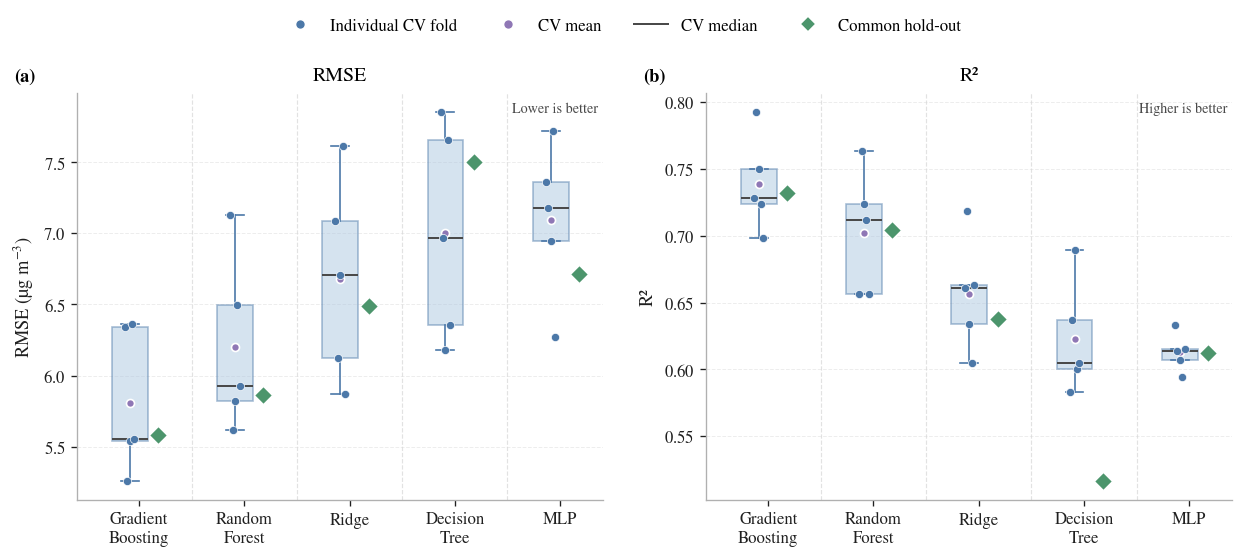

In [20]:
fig_3, axes_3 = (
    benchmark_plots
    .plot_cv_test_comparison(
        benchmark_results=(
            benchmark_results
        ),
        fold_results=train_cv_fold_results,
        output_path=(
            RESULTS_DIR
            / "cv_vs_common_holdout.png"
        ),
        model_order=comparison_summary["Model"].tolist(),
        figure_size=(10.5, 4.6),
        cv_color=COLORS["primary_light"],
        fold_point_color=COLORS["primary"],
        mean_color=COLORS["tertiary"],
        median_color=COLORS["reference"],
        test_color=COLORS["secondary"],
        separator_color=COLORS["grid"],
        dpi=300,
    )
)

plt.show()

### 3.3 Supplementary dimensionless metrics

MAPE, SMAPE, and NRMSE are reported as supplementary dimensionless error metrics. They support comparisons across concentration levels but do not replace MAE, RMSE, or R² as the primary model-selection criteria.


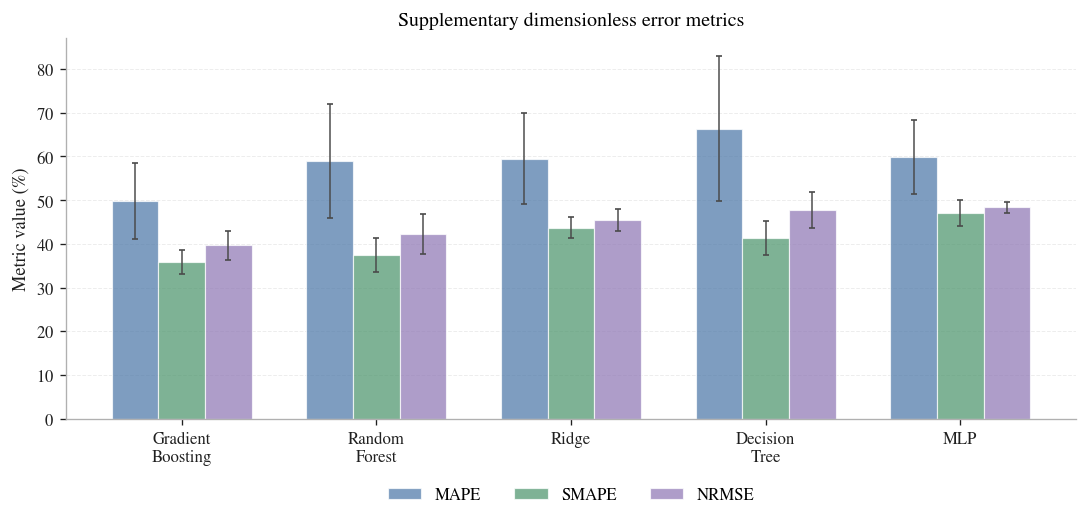

In [21]:
fig_5, ax_5 = benchmark_plots.plot_dimensionless_metric_comparison(
    benchmark_results=benchmark_results,
    output_path=RESULTS_DIR / "dimensionless_metric_comparison.png",
    model_order=comparison_summary["Model"].tolist(),
    figure_size=(9.2, 4.8),
    dpi=300,
)
plt.show()


## 4. Selected-Model Prediction Diagnostics

Diagnostics focus on the model selected by development CV. They assess
hold-out agreement, concentration-dependent error, and extrapolation
beyond the PM2.5 range represented in the development data.

In [22]:
# Select the model using development cross-validation only.
BEST_MODEL_NAME = (
    benchmark_cv_results
    .sort_values(["CV R2", "CV RMSE"], ascending=[False, True])
    .iloc[0]["Model"]
)

# Summarise error and coverage across policy-relevant concentration ranges.
range_predictions = predictions[BEST_MODEL_NAME].copy()
range_predictions["Date"] = pd.to_datetime(
    final_test_df["time"].to_numpy()
).normalize()
range_predictions["Error"] = (
    range_predictions["Predicted"] - range_predictions["Observed"]
)
range_predictions["Absolute Error"] = range_predictions["Error"].abs()
range_predictions["Squared Error"] = range_predictions["Error"] ** 2

range_order = ["≤20", "20–35", ">35"]
range_predictions["PM2.5 Range"] = pd.cut(
    range_predictions["Observed"],
    bins=[-np.inf, 20, 35, np.inf],
    labels=range_order,
    include_lowest=True,
)
range_summary = (
    range_predictions
    .groupby("PM2.5 Range", observed=False)
    .agg(
        Samples=("Observed", "size"),
        Independent_Dates=("Date", "nunique"),
        MAE=("Absolute Error", "mean"),
        RMSE=("Squared Error", lambda values: np.sqrt(values.mean())),
        Mean_Bias=("Error", "mean"),
    )
    .reindex(range_order)
    .reset_index()
    .rename(columns={
        "Independent_Dates": "Independent Dates",
        "Mean_Bias": "Mean Bias",
    })
)
display(range_summary.round(3))


,PM2.5 Range,Samples,Independent Dates,MAE,RMSE,Mean Bias
0,≤20,571,38,3.229,4.241,0.817
1,20–35,110,24,6.601,7.996,-2.521
2,>35,39,5,9.117,11.479,-5.410


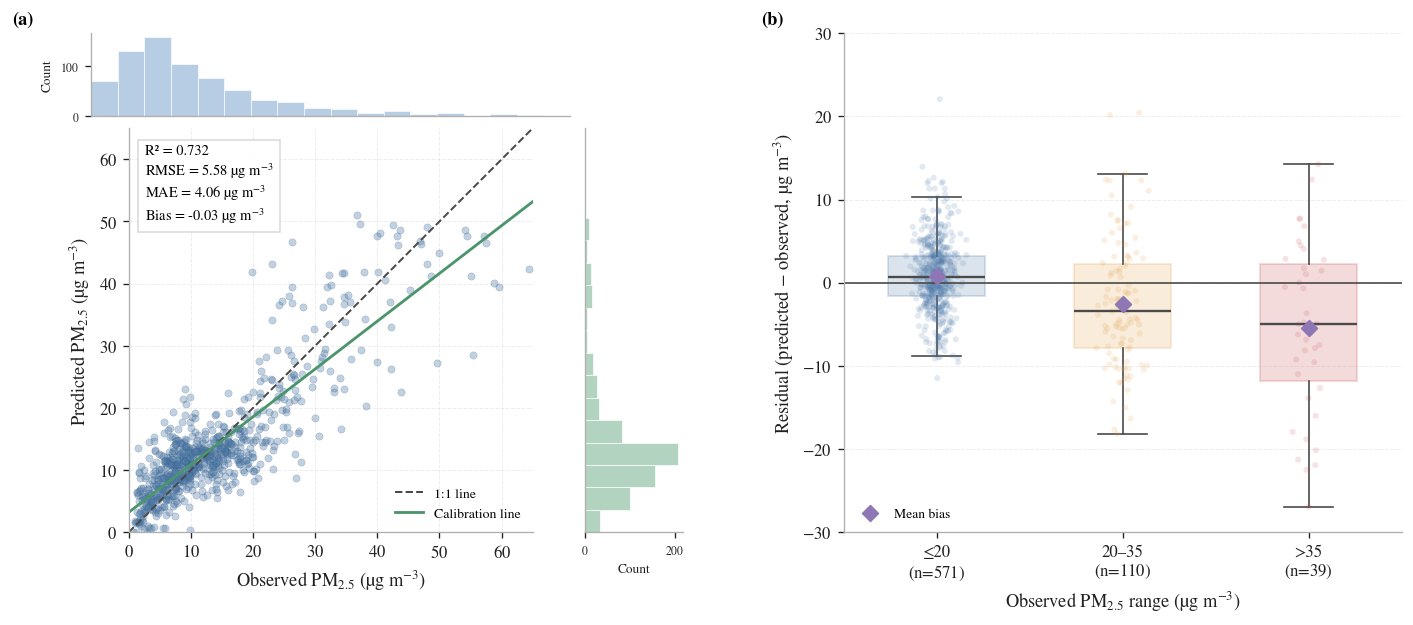

In [23]:

# Plot hold-out agreement, marginal distributions, and residual behaviour.
DEVELOPMENT_MAXIMUM = float(development_df[TARGET].max())

fig_4, axes_4 = benchmark_plots.plot_best_model_holdout_diagnostics(
    predictions=predictions,
    benchmark_results=benchmark_results,
    model_name=BEST_MODEL_NAME,
    development_maximum=DEVELOPMENT_MAXIMUM,
    concentration_thresholds=(20, 35),
    output_path=RESULTS_DIR / "best_model_holdout_diagnostics.png",
    figure_size=(12.0, 5.2),
    point_color=COLORS["primary"],
    point_edge_color=COLORS["primary_dark"],
    residual_color=COLORS["secondary_light"],
    trend_color=COLORS["secondary"],
    residual_trend_color=COLORS["tertiary"],
    threshold_colors=(COLORS["moderate"], COLORS["high"]),
    development_color=COLORS["tertiary"],
)

RANGE_SUMMARY_PATH = RESULTS_DIR / "best_model_concentration_summary.csv"
range_summary.to_csv(RANGE_SUMMARY_PATH, index=False)
plt.show()

## 5. Supplementary Analyses


### 5.1 Clean-Air Reference Normalization

This exploratory experiment tests whether low-concentration images can provide
reference statistics for image-feature normalization. Low-concentration
conditions are operationally defined as PM2.5 ≤ 20 µg m⁻³, consistent with
the concentration ranges used throughout the analysis.


In [24]:
# Estimate reference statistics within each training fold to prevent leakage.
CLEAN_AIR_LIMIT = 20.0
selected_model = benchmark_models[BEST_MODEL_NAME]

(
    clean_reference_results,
    clean_reference_fold_results,
    clean_reference_cv_predictions,
    clean_reference_test_predictions,
) = evaluation.evaluate_clean_reference_comparison(
    model=selected_model,
    model_name=BEST_MODEL_NAME,
    model_features=FEATURES,
    reference_features=config.IMAGE_FEATURES,
    development_df=development_df,
    test_df=final_test_df,
    target=TARGET,
    n_splits=N_SPLITS,
    random_state=MODEL_RANDOM_STATE,
    group_column="date_group",
    clean_limit=CLEAN_AIR_LIMIT,
    condition_columns=("month", "is_daytime"),
    minimum_reference_samples=10,
)

cv_reference_summary = clean_reference_results[[
    "Representation",
    "CV MAE", "CV MAE Std",
    "CV RMSE", "CV RMSE Std",
    "CV R2", "CV R2 Std",
]].copy()
display(cv_reference_summary.round(3))


,Representation,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Raw,4.380,0.359,5.810,0.508,0.739,0.036
1,Clean-reference normalized,4.414,0.359,5.821,0.519,0.738,0.032


In [25]:
# Compare raw and normalized validation errors across concentration ranges.
(
    clean_reference_range_summary,
    clean_reference_range_display,
) = benchmark.summarize_clean_reference_by_concentration(
    predictions=clean_reference_cv_predictions,
    thresholds=(20, 35),
)
display(clean_reference_range_display.round(3))


,PM2.5 Range,Samples,Raw MAE,Normalized MAE,MAE change,Raw bias,Normalized bias
0,≤20,2328,3.525,3.550,0.025,1.251,1.165
1,20–35,350,7.768,7.723,-0.044,-4.508,-4.535
2,>35,227,7.928,8.177,0.248,-6.047,-6.294


,Representation,Test MAE,Test RMSE,Test R2
0,Raw,4.063,5.583,0.732
1,Clean-reference normalized,4.201,5.778,0.713


,Metric,Development CV change,Common hold-out change
0,MAE,0.034,0.138
1,RMSE,0.011,0.194
2,R2,-0.001,-0.019


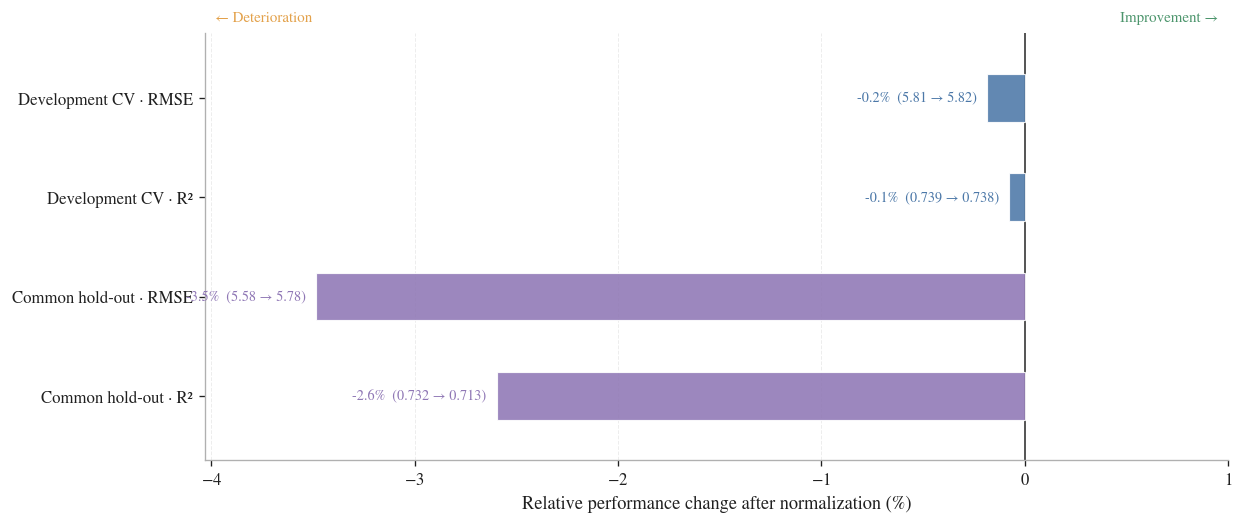

In [26]:
# Use the common hold-out only as an independent confirmation.
holdout_reference_summary = clean_reference_results[[
    "Representation", "Test MAE", "Test RMSE", "Test R2"
]].copy()
display(holdout_reference_summary.round(3))

raw_result = clean_reference_results.loc[
    clean_reference_results["Representation"].eq("Raw")
].iloc[0]
normalized_result = clean_reference_results.loc[
    clean_reference_results["Representation"].eq(
        "Clean-reference normalized"
    )
].iloc[0]
reference_change_summary = pd.DataFrame([
    {
        "Metric": metric,
        "Development CV change": (
            normalized_result[f"CV {metric}"] - raw_result[f"CV {metric}"]
        ),
        "Common hold-out change": (
            normalized_result[f"Test {metric}"] - raw_result[f"Test {metric}"]
        ),
    }
    for metric in ("MAE", "RMSE", "R2")
])
display(reference_change_summary.round(3))

fig_7, axes_7 = benchmark_plots.plot_clean_reference_fold_distributions(
    comparison_results=clean_reference_results,
    fold_results=clean_reference_fold_results,
    output_path=RESULTS_DIR / "clean_reference_comparison.png",
    figure_size=(10.5, 4.5),
    raw_color=plot_style.COLORS["primary"],
    normalized_color=plot_style.COLORS["secondary"],
    holdout_color=plot_style.COLORS["tertiary"],
    dpi=300,
)
plt.show()

clean_reference_exports = {
    "clean_reference_results.csv": clean_reference_results,
    "clean_reference_fold_results.csv": clean_reference_fold_results,
    "clean_reference_cv_predictions.csv": clean_reference_cv_predictions,
    "clean_reference_range_summary.csv": clean_reference_range_summary,
    "clean_reference_holdout_predictions.csv": clean_reference_test_predictions,
    "clean_reference_change_summary.csv": reference_change_summary,
}
for filename, frame in clean_reference_exports.items():
    frame.to_csv(RESULTS_DIR / filename, index=False)


### 5.2 Validation-Strategy Sensitivity

The selected model is evaluated using a 2 × 2 comparison of the common and
strict temporal hold-outs, with and without equal-year-month weighting. This
separates the effect of month weighting from the effect of future-period
generalization. The strict temporal hold-out comprises the most recent 20% of
independent dates and is interpreted as a directional stress test; repeated
date-split uncertainty is examined in a separate sensitivity diagnostic.


In [27]:
# Compare split strategy and equal-year-month weighting separately.
selected_model = benchmark_models[BEST_MODEL_NAME]

balanced_common_metrics, _ = evaluation.evaluate_holdout(
    model=selected_model,
    feature_list=FEATURES,
    development_df=development_df,
    test_df=final_test_df,
    target=TARGET,
    balance_column="year_month",
)

temporal_development_df, temporal_test_df = evaluation.temporal_split(
    benchmark_df,
    time_column="time",
    test_size=FINAL_TEST_SIZE,
)
if set(temporal_development_df["date_group"]) & set(
    temporal_test_df["date_group"]
):
    raise ValueError("Temporal development and hold-out sets share dates.")
if temporal_development_df["time"].max() >= temporal_test_df["time"].min():
    raise ValueError("Temporal hold-out observations are not strictly later.")

temporal_unweighted_metrics, _ = evaluation.evaluate_holdout(
    model=selected_model,
    feature_list=FEATURES,
    development_df=temporal_development_df,
    test_df=temporal_test_df,
    target=TARGET,
    balance_column=None,
)

temporal_weighted_metrics, _ = evaluation.evaluate_holdout(
    model=selected_model,
    feature_list=FEATURES,
    development_df=temporal_development_df,
    test_df=temporal_test_df,
    target=TARGET,
    balance_column="year_month",
)

common_unweighted = (
    benchmark_results
    .loc[benchmark_results["Model"].eq(BEST_MODEL_NAME)]
    .iloc[0]
)

def validation_row(strategy, weighting, holdout, metrics):
    return {
        "Strategy": strategy,
        "Month weighting": weighting,
        "Samples": len(holdout),
        "Independent dates": holdout["date_group"].nunique(),
        "Observed months": holdout["year_month"].nunique(),
        "Start": holdout["time"].min(),
        "End": holdout["time"].max(),
        "Mean PM2.5": holdout[TARGET].mean(),
        "PM2.5 SD": holdout[TARGET].std(),
        "Maximum PM2.5": holdout[TARGET].max(),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
    }

validation_strategy_summary = pd.DataFrame([
    validation_row(
        "Common hold-out", "None", final_test_df,
        {
            "MAE": common_unweighted["Test MAE"],
            "RMSE": common_unweighted["Test RMSE"],
            "R2": common_unweighted["Test R2"],
        },
    ),
    validation_row(
        "Common hold-out", "Equal year-month", final_test_df,
        balanced_common_metrics,
    ),
    validation_row(
        "Strict temporal hold-out", "None", temporal_test_df,
        temporal_unweighted_metrics,
    ),
    validation_row(
        "Strict temporal hold-out", "Equal year-month", temporal_test_df,
        temporal_weighted_metrics,
    ),
])

display(validation_strategy_summary.round(3))
validation_strategy_summary.to_csv(
    RESULTS_DIR / "validation_strategy_sensitivity.csv",
    index=False,
)


,Strategy,Month weighting,Samples,Independent dates,Observed months,Start,End,Mean PM2.5,PM2.5 SD,Maximum PM2.5,MAE,RMSE,R2
0,Common hold-out,None,720,42,13,2025-01-30 03:00:00,2026-08-07 21:00:00,13.985,10.789,64.351,4.063,5.583,0.732
1,Common hold-out,Equal year-month,720,42,13,2025-01-30 03:00:00,2026-08-07 21:00:00,13.985,10.789,64.351,4.391,5.855,0.702
2,Strict temporal hold-out,None,799,42,3,2026-06-30 02:00:00,2026-08-12 21:00:00,12.374,5.527,33.874,4.353,5.569,-0.017
3,Strict temporal hold-out,Equal year-month,799,42,3,2026-06-30 02:00:00,2026-08-12 21:00:00,12.374,5.527,33.874,5.566,6.655,-0.683
